In [17]:
# Cell 1: 路径、autoreload、import
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import warnings
import torch
warnings.filterwarnings("ignore", category=UserWarning)

from configs.default_config import Config
from core.builder import build_train_runner
from evaluation.reward_plots import plot_reward_decomposition
from evaluation.plots import plot_last_k_episodes_price_action_soc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Cell 2: args = Config() 以及实验配置切换
# =============================================================
# 实验配置：在这里切换，其余代码不用改
# =============================================================
args = Config()
args.algorithm              = "MADDPG"           # "MADDPG" | "MATD3"
args.reward_type            = "composite"        # "composite" | "sparse"
args.actor_type             = "mlp"              # "mlp"（可扩展 "lstm" 等）
args.forecaster_type        = "perfect"          # "perfect" | "naive" | "lstm"
args.dataset_type           = "csv_price_load"   # 数据集类型（当前唯一可选项）
args.observation_builder_type = "default"        # 观测构造器类型

# critic_type 留空即可，builder 会按 algorithm 自动解析并校验兼容性
args.critic_type = None

# 同步 device 到 args，供 agent 构建网络时使用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.device = device
# =============================================================

print(f"Using device: {device}")
print(f"Algorithm={args.algorithm}  Reward={args.reward_type}  Forecaster={args.forecaster_type}")

Using device: cuda
Algorithm=MADDPG  Reward=composite  Forecaster=perfect


In [19]:
# Cell 3: 构建 runner + sanity check
import multiprocessing as mp
try:
    mp.set_start_method("spawn")
except RuntimeError:
    pass

runner = build_train_runner(args, seed=0, env_name="EnergyStorageEnv", number=1)

print("\n" + "="*40)
print("Observation Space Check")
print("="*40)
obs_dim = runner.args.obs_dim_n[0]
print(f"obs_dim per agent = {obs_dim} (expected 2 + 2*(K+1) + 1 = {2 + 2*(24+1) + 1})")
sample_obs_n = runner.env.reset()
print("batched obs shape (agent0):", sample_obs_n[0].shape)  # (num_envs, obs_dim)
print("="*40 + "\n")


Observation Space Check
obs_dim per agent = 53 (expected 2 + 2*(K+1) + 1 = 53)
batched obs shape (agent0): (32, 53)



In [20]:
# Cell 4: 训练 + 保存模型
trained_episodes = runner.run()

model_save_dir = "./saved_models"
save_tag = runner.episodes_completed  # 以实际完成的 episode 数作为保存 tag；并行训练下它可能与 Config.train_episodes 不完全相等
runner.save_model(model_save_dir, episode=save_tag)

Training (Parallel):   0%|          | 0/600 [00:00<?, ?iters/s]

Models saved to: ./saved_models\MADDPG


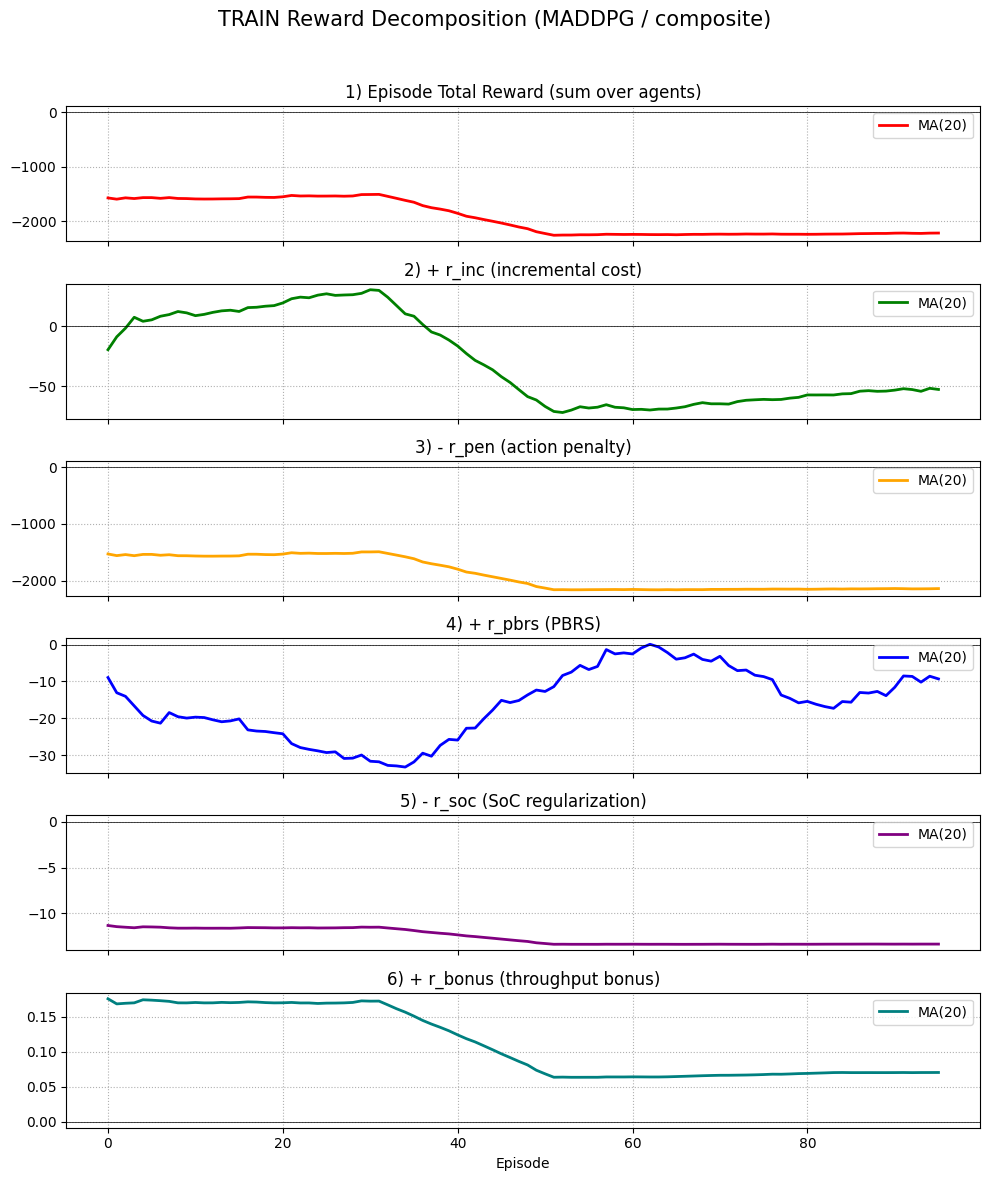

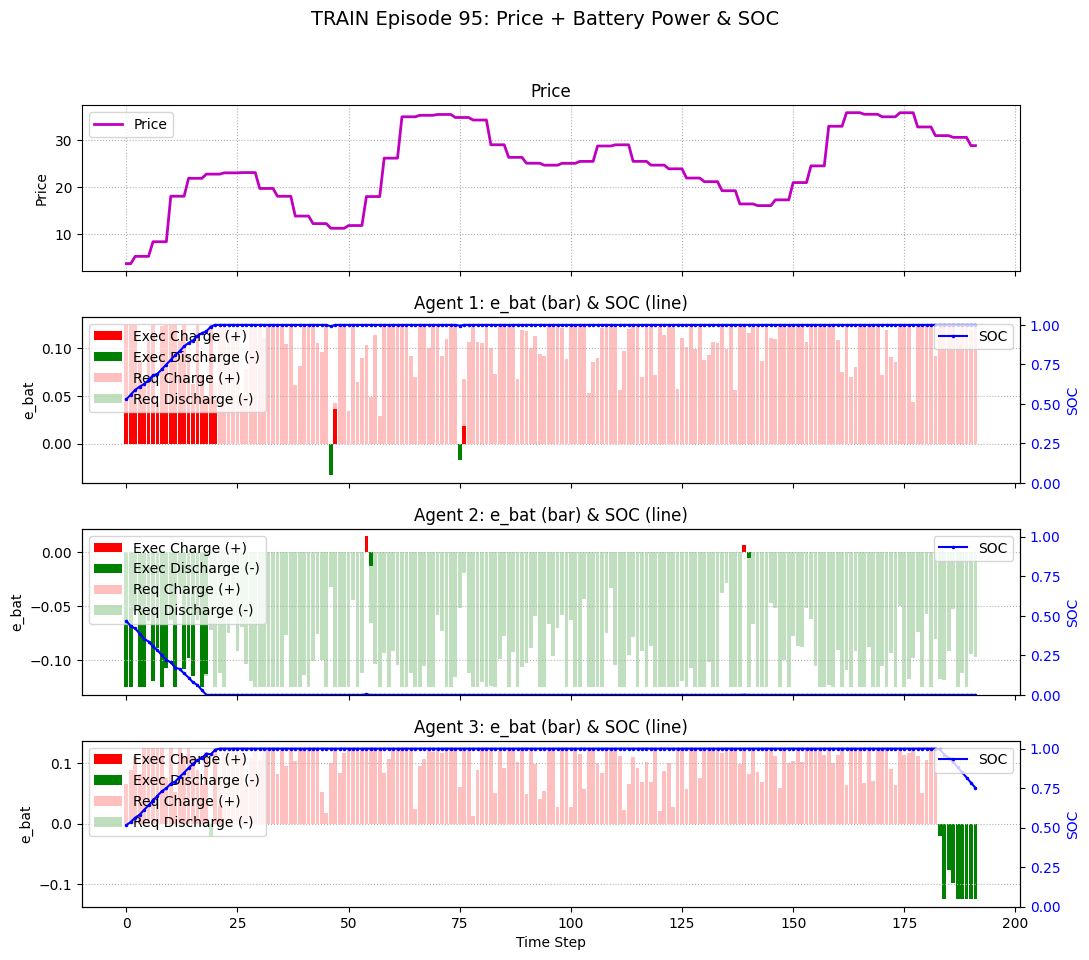

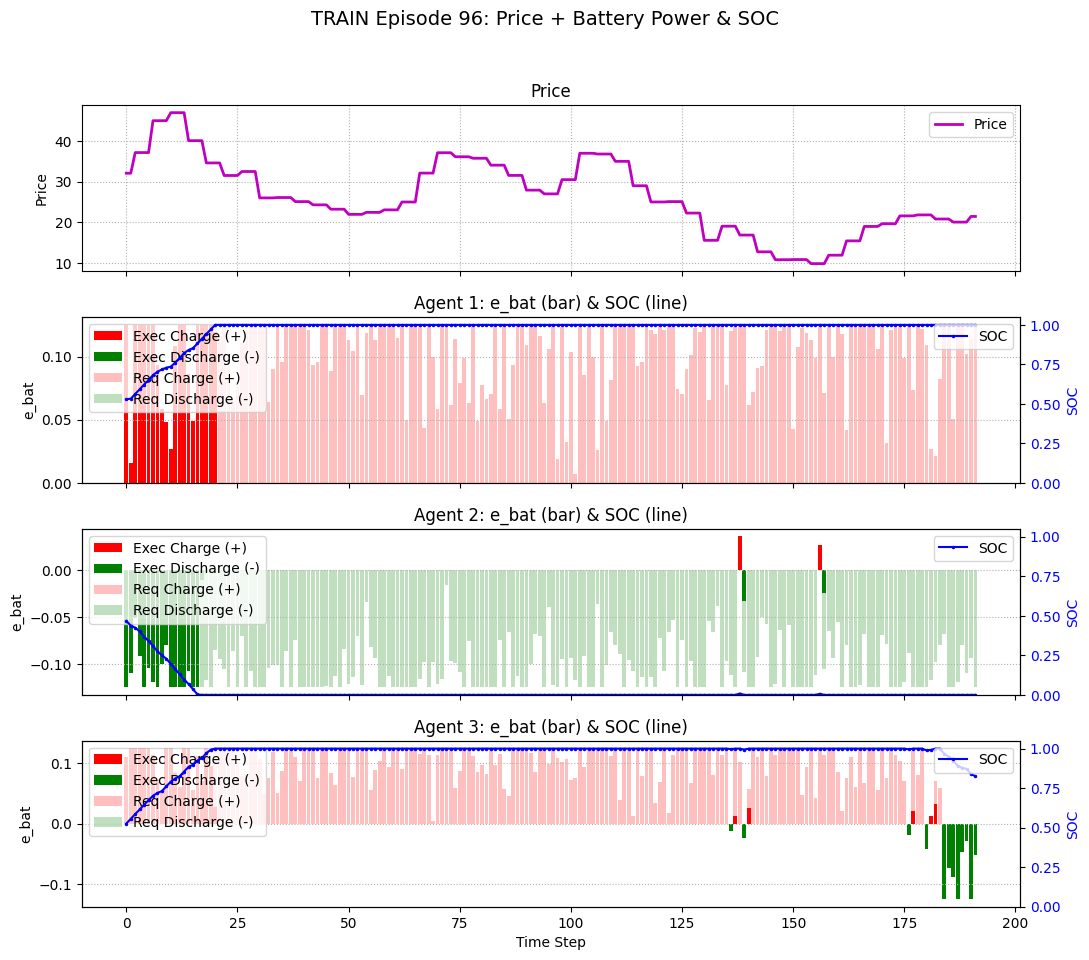

In [21]:
# Cell 5: 评估画图
plot_reward_decomposition(
    history=runner.history,
    episode_rewards=runner.episode_rewards,
    reward_fn=runner.env_evaluate.reward_fn,
    title=f"TRAIN Reward Decomposition ({args.algorithm} / {args.reward_type})",
    window=20,
)

plot_last_k_episodes_price_action_soc(
    history=runner.history,
    k=2,
    n_agents=args.N,
    title_prefix="TRAIN",
)